# 03.1 Time-Series Dataset Validation

Este notebook valida el dataset secuencial que alimenta a `PriceSequenceGRU`.

**Objetivo**
- reconstruir `data/processed_ts/` de forma reproducible
- verificar cobertura, balance y longitud de secuencias
- revisar ejemplos reales de series truncadas al snapshot
- comprobar visualmente que no hay leakage temporal

**Salida esperada**
- archivos en `data/processed_ts/`
- figuras de validación en `figures/`
- confianza en que el dataset TS está listo antes de entrenar

## 1. Setup y reproducibilidad

Esta celda centraliza imports, paths y estilo visual. Si falla aquí, el resto del notebook no tiene estado confiable.

In [7]:
import sys
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT))

from src.config import load_config
from src.features.pipeline import build_and_save_from_raw
from src.features.ts_sequence import build_market_price_sequence, extract_sequence_points
from src.data.preprocessing import get_snapshot_cutoff_time

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
})
PALETTE = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

cfg = load_config(str(ROOT / 'config' / 'config.yaml'))
RAW = ROOT / 'data' / 'raw'
PROCESSED = ROOT / cfg['data']['processed_dir']
PROCESSED_TS = ROOT / cfg['ts_data']['processed_dir']
FIGURES = ROOT / 'figures'
FIGURES.mkdir(exist_ok=True)
print('Output TS dir:', PROCESSED_TS)

RUN_PIPELINE = False  # True = reconstruye datasets tabular+TS desde raw


Output TS dir: /Users/andres/Documents/ITAM/octavo_semestre/mineria_y_analisis/proyecto_polymarket/data/processed_ts


## 2. Reconstrucción del dataset TS

Usamos el builder actual del pipeline snapshot. Si `RUN_PIPELINE=True`, se regeneran `data/processed/` y `data/processed_ts/` desde `data/raw/` con el contrato nuevo.


In [8]:
with open(RAW / 'resolved_markets.json') as f:
    resolved_markets = json.load(f)
with open(RAW / 'price_histories.json') as f:
    price_histories = json.load(f)

if RUN_PIPELINE:
    metadata_ts = build_and_save_from_raw(
        input_dir=RAW,
        tabular_output_dir=PROCESSED,
        ts_output_dir=PROCESSED_TS,
        horizons_days=cfg['features']['snapshot_horizons_days'],
        lookback_days=cfg['ts_data']['sequence_lookback_days'],
        step_hours=cfg['ts_data']['sequence_grid_hours'],
        use_dummy_text=cfg['features'].get('use_dummy_text', False),
    )
    print('Datasets reconstruidos y guardados.')
    print(json.dumps(metadata_ts, indent=2))
else:
    print(f'RUN_PIPELINE={RUN_PIPELINE} -> usando artefactos en {PROCESSED_TS}')
    assert (PROCESSED_TS / 'sequences.npy').exists(),         f'No existe {PROCESSED_TS} — activa RUN_PIPELINE=True o corre: python -m src.features.pipeline'


RUN_PIPELINE=False -> usando artefactos en /Users/andres/Documents/ITAM/octavo_semestre/mineria_y_analisis/proyecto_polymarket/data/processed_ts


## 3. Carga y chequeos rápidos del artefacto guardado

Antes de visualizar, conviene revisar shapes, buy rate y metadata persistida para asegurar que el notebook está leyendo exactamente lo que acaba de guardar.

In [9]:
sequences = np.load(PROCESSED_TS / 'sequences.npy')
lengths = np.load(PROCESSED_TS / 'sequence_lengths.npy')
labels = np.load(PROCESSED_TS / 'labels.npy')
end_dates = np.load(PROCESSED_TS / 'end_dates.npy')
market_ids = np.load(PROCESSED_TS / 'market_ids.npy', allow_pickle=True)
snapshot_prices = np.load(PROCESSED_TS / 'snapshot_prices.npy')
metadata_saved = json.loads((PROCESSED_TS / 'metadata.json').read_text())

print(f'Secuencias:       {sequences.shape}')
print(f'Longitudes:       {lengths.shape} | min={lengths.min()} median={np.median(lengths):.0f} max={lengths.max()}')
print(f'Labels:           {labels.shape} | buy rate={100 * labels.mean():.1f}%')
print(f'Snapshot prices:  mean={snapshot_prices.mean():.3f} std={snapshot_prices.std():.3f}')
print('Metadata saved:')
print(json.dumps(metadata_saved, indent=2))


Secuencias:       (39545, 60, 3)
Longitudes:       (39545,) | min=60 median=60 max=60
Labels:           (39545,) | buy rate=31.2%
Snapshot prices:  mean=0.360 std=0.334
Metadata saved:
{
  "num_samples": 39545,
  "num_markets": 13373,
  "snapshot_horizons_days": [
    1,
    3,
    7,
    14,
    30
  ],
  "sequence_lookback_days": 30,
  "sequence_grid_hours": 12,
  "tabular_feature_names": [
    "snapshot_price_yes",
    "days_to_end",
    "market_age_days_at_snapshot",
    "days_since_last_trade",
    "history_points_1d",
    "history_points_3d",
    "history_points_7d",
    "history_points_30d",
    "history_span_days",
    "return_1d",
    "return_3d",
    "return_7d",
    "return_14d",
    "return_30d",
    "realized_vol_1d",
    "realized_vol_3d",
    "realized_vol_7d",
    "realized_vol_14d",
    "realized_vol_30d",
    "trend_slope_7d",
    "trend_slope_30d",
    "price_percentile_30d",
    "distance_to_30d_min",
    "distance_to_30d_max",
    "neg_risk"
  ],
  "sequence_featur

## 4. Cobertura y balance del dataset

Aquí revisamos dos riesgos clásicos del dataset secuencial:
- que la retención sea demasiado baja por falta de historia válida
- que el balance de labels cambie mucho respecto al pipeline base

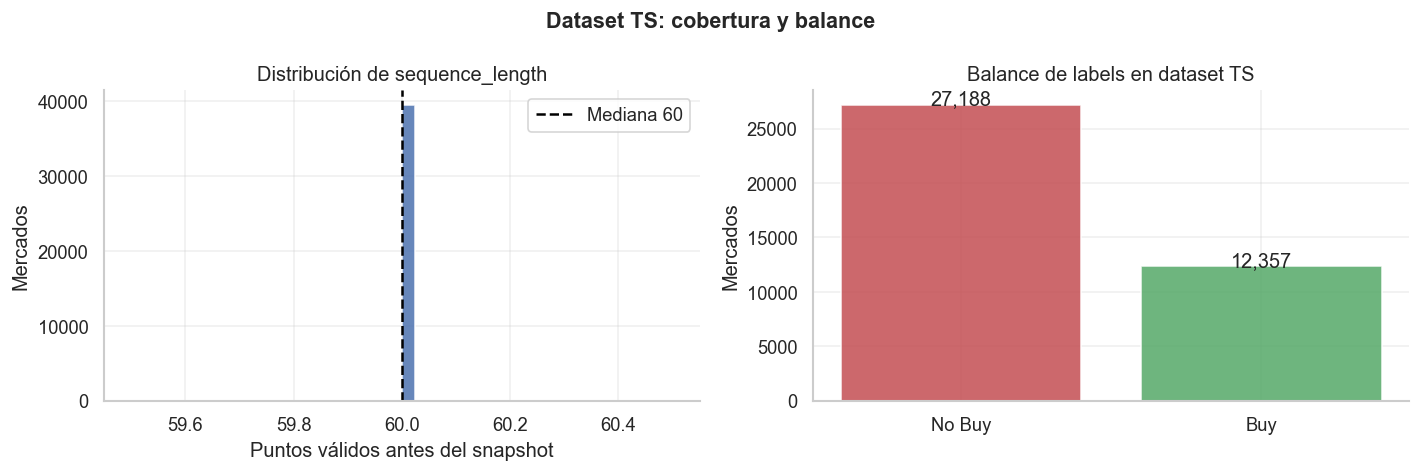

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.hist(lengths, bins=40, color=PALETTE[0], alpha=0.85)
ax.axvline(np.median(lengths), color='black', linestyle='--', lw=1.5, label=f'Mediana {np.median(lengths):.0f}')
ax.set_title('Distribución de sequence_length')
ax.set_xlabel('Puntos válidos antes del snapshot')
ax.set_ylabel('Mercados')
ax.legend()

ax = axes[1]
bars = ax.bar(['No Buy', 'Buy'], [(1 - labels).sum(), labels.sum()], color=[PALETTE[3], PALETTE[2]], alpha=0.85)
for bar, count in zip(bars, [(1 - labels).sum(), labels.sum()]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20, f'{int(count):,}', ha='center')
ax.set_title('Balance de labels en dataset TS')
ax.set_ylabel('Mercados')

plt.suptitle('Dataset TS: cobertura y balance', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES / 'ts_dataset_lengths.png', bbox_inches='tight')
plt.show()


## 5. Relación entre snapshot price y label

Si el snapshot price está muy concentrado o muy extremo, el modelo secuencial tendría poco espacio para aprender patrones temporales más ricos.

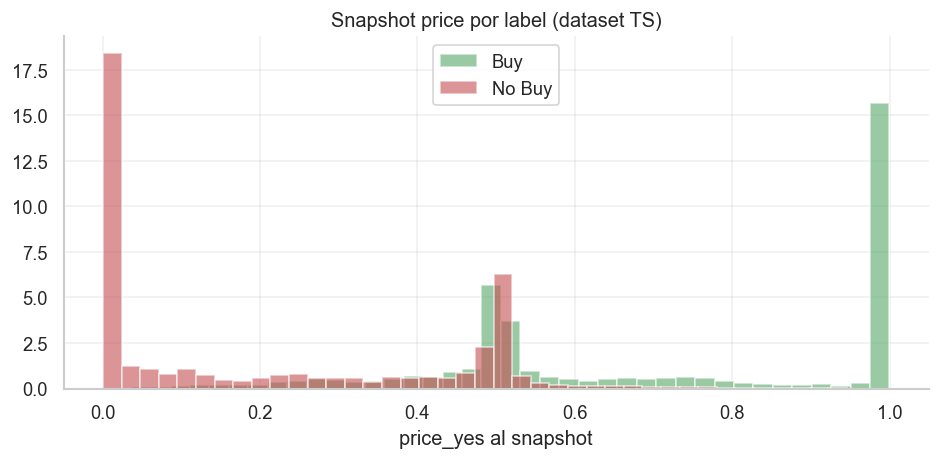

In [11]:
fig, ax = plt.subplots(figsize=(8, 4))
for val, color, label in [(1, PALETTE[2], 'Buy'), (0, PALETTE[3], 'No Buy')]:
    ax.hist(snapshot_prices[labels == val], bins=40, alpha=0.6, color=color, density=True, label=label)
ax.set_title('Snapshot price por label (dataset TS)')
ax.set_xlabel('price_yes al snapshot')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES / 'ts_dataset_labels.png', bbox_inches='tight')
plt.show()


## 6. Ejemplos reales de secuencias

Mostramos una secuencia corta, una mediana y una larga para inspeccionar visualmente el tipo de trayectorias que sí llegan al modelo.

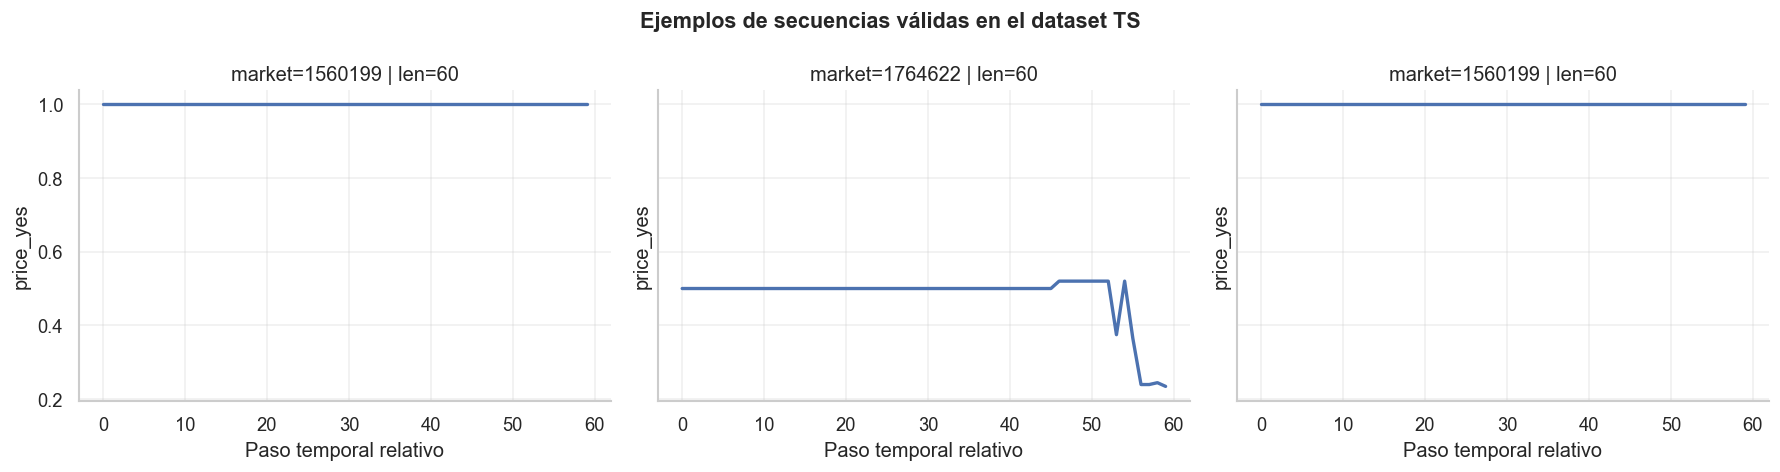

In [12]:
idxs = [int(np.argmin(lengths)), int(np.argsort(lengths)[len(lengths)//2]), int(np.argmax(lengths))]
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, idx in zip(axes, idxs):
    seq = sequences[idx]
    length = int(lengths[idx])
    valid = seq[-length:]
    x = np.arange(length)
    ax.plot(x, valid[:, 0], color=PALETTE[0], lw=2)
    ax.set_title(f'market={market_ids[idx]} | len={length}')
    ax.set_xlabel('Paso temporal relativo')
    ax.set_ylabel('price_yes')

plt.suptitle('Ejemplos de secuencias válidas en el dataset TS', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES / 'ts_sequence_examples.png', bbox_inches='tight')
plt.show()


## 7. Validación anti-leakage

Esta última verificación confirma que el builder TS solo consume puntos con `t <= snapshot_cutoff`. La zona gris representa historia real que existe, pero que el modelo **no** ve.

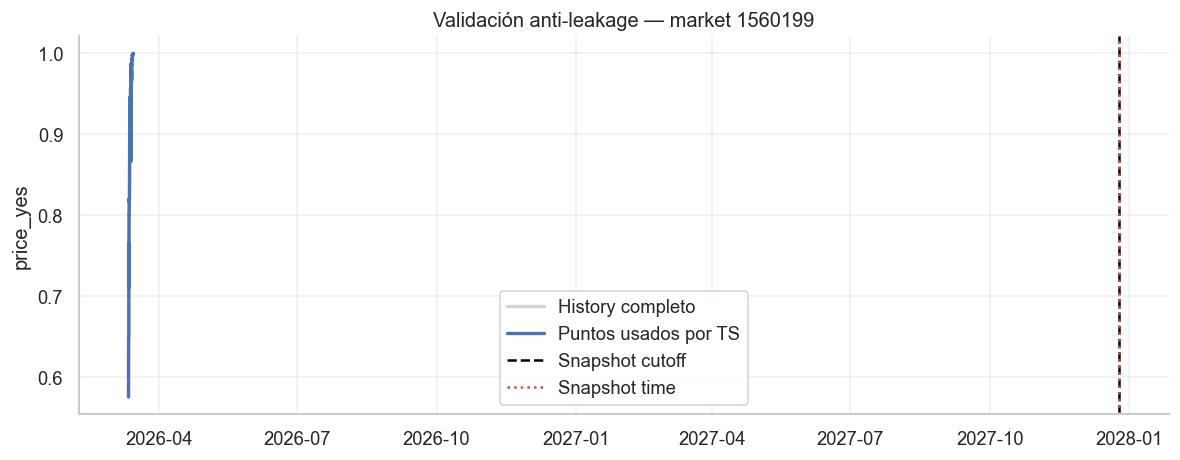

Puntos completos: 72
Puntos usados TS: 72
Puntos excluidos post-cutoff: 0
Snapshot cutoff: 2027-12-25 05:00:00+00:00


In [13]:
sample_market = next(m for m in resolved_markets if str(m.get('id')) == str(market_ids[np.argmax(lengths)]))
snapshot_offset_days = int(cfg['ts_data'].get('snapshot_offset_days', 7))
cutoff = get_snapshot_cutoff_time(sample_market, snapshot_offset_days=snapshot_offset_days)
history = price_histories[str(sample_market['id'])]
points_all = extract_sequence_points(history, cutoff_time=None)
points_cut = extract_sequence_points(history, cutoff_time=cutoff)
_, _, _, snapshot_time = build_market_price_sequence(
    sample_market,
    price_histories=price_histories,
    snapshot_offset_days=snapshot_offset_days,
    lookback_days=cfg['ts_data']['sequence_lookback_days'],
    step_hours=cfg['ts_data']['sequence_grid_hours'],
)

df_all = pd.DataFrame({'time': [t for t, _ in points_all], 'price': [p for _, p in points_all]})
df_cut = pd.DataFrame({'time': [t for t, _ in points_cut], 'price': [p for _, p in points_cut]})

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(df_all['time'], df_all['price'], color='lightgray', lw=2, label='History completo')
ax.plot(df_cut['time'], df_cut['price'], color=PALETTE[0], lw=2, label='Puntos usados por TS')
ax.axvline(cutoff, color='black', linestyle='--', lw=1.5, label='Snapshot cutoff')
if snapshot_time is not None:
    ax.axvline(snapshot_time, color=PALETTE[3], linestyle=':', lw=1.5, label='Snapshot time')
ax.set_title(f"Validación anti-leakage — market {sample_market['id']}")
ax.set_ylabel('price_yes')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES / 'ts_snapshot_validation.png', bbox_inches='tight')
plt.show()

print('Puntos completos:', len(df_all))
print('Puntos usados TS:', len(df_cut))
print('Puntos excluidos post-cutoff:', len(df_all) - len(df_cut))
print('Snapshot cutoff:', cutoff)


## 8. Checklist antes de entrenar

Si este notebook sale bien, el dataset TS ya debería cumplir estas condiciones:
- `data/processed_ts/` existe y tiene shapes consistentes
- las secuencias tienen longitudes razonables
- el buy rate no es patológico
- el cutoff temporal excluye puntos posteriores al snapshot

Con eso, el siguiente paso natural es `04_1_ts_model_training.ipynb`.